# Primera Entrega Proyecto Final


### Librerias:

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
import math

### Importar Datos:

In [5]:
df = pd.read_csv('diabetic_data.csv')

### Limpieza de Datos:

In [6]:
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df)) * 100

tabla_faltantes = pd.DataFrame({
    'Valores faltantes': faltantes,
    'Porcentaje (%)': porcentaje
})

# Mostrar solo columnas con NA
tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0]
tabla_faltantes.sort_values('Porcentaje (%)', ascending=False)

,Valores faltantes,Porcentaje (%)
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322


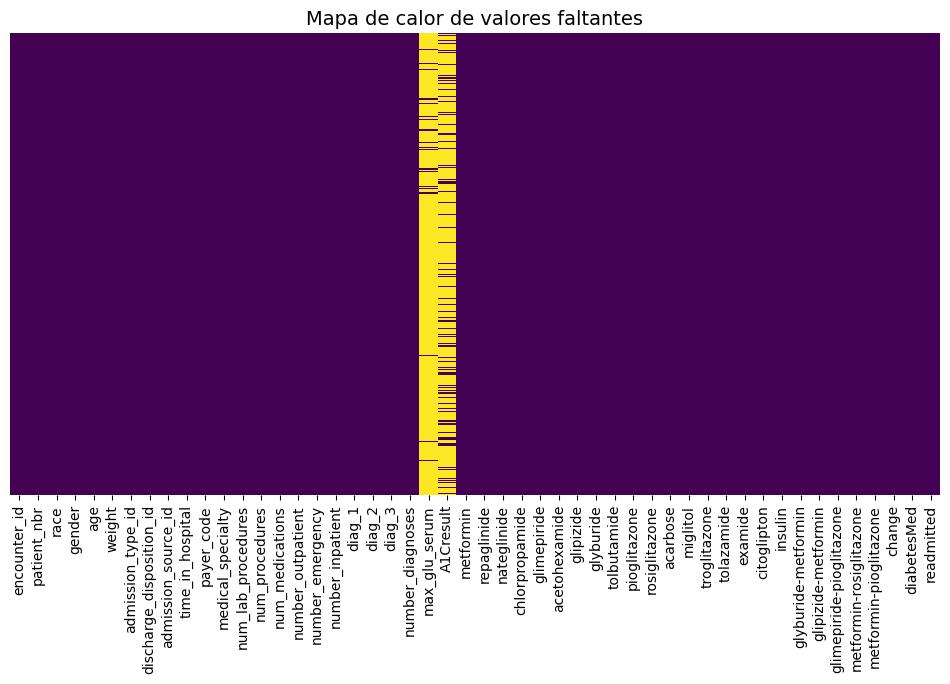

In [3]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Mapa de calor de valores faltantes", fontsize=14)
plt.show()

In [4]:
cat_cols = df.select_dtypes(include='object').columns

#Se reemplaza los "na" que en realidad son una categoria por el string none
df['max_glu_serum'] = df['max_glu_serum'].fillna('none')
df['A1Cresult'] =df['A1Cresult'].fillna('none')

# Reemplazar '?' por NaN
df[cat_cols] = df[cat_cols].replace('?', np.nan)

faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df)) * 100

tabla_faltantes = pd.DataFrame({
    'Valores faltantes': faltantes,
    'Porcentaje (%)': porcentaje
})

# Mostrar solo columnas con NA
tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0]
tabla_faltantes.sort_values('Porcentaje (%)', ascending=False)

,Valores faltantes,Porcentaje (%)
weight,98569,96.858479
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


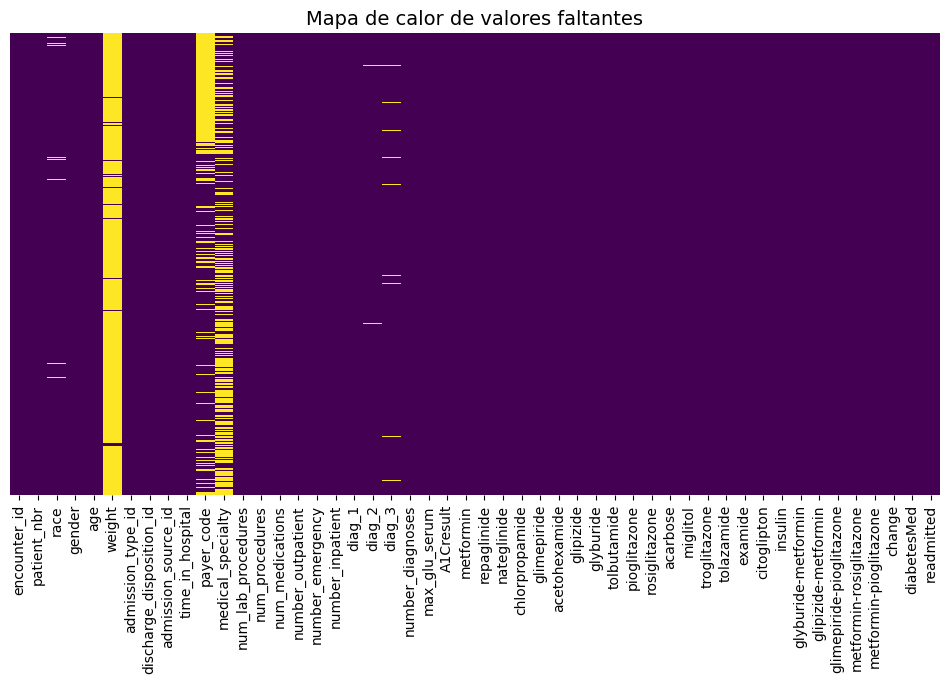

In [5]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Mapa de calor de valores faltantes", fontsize=14)
plt.show()

La columna Weight sera eliminada dado el alto porcentaje de NA que tiene, en race se hara imputación por la moda ya que los datos faltantes son aleatorios y representan menos del 6% de la muestra

In [6]:
df.drop(columns=['weight'], inplace=True) #Se elimina

#imputación por la moda
moda_race = df['race'].mode()[0]  # Obtiene el valor más frecuente
df['race'] = df['race'].fillna(moda_race)

#remplazamos los na por categorias dado que son porcentajes grandes o irrelevantes para imputar
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
df['payer_code'] = df['payer_code'].fillna('Unknown')
df['diag_1'] = df['diag_1'].fillna('Missing')
df['diag_2'] = df['diag_2'].fillna('Missing')
df['diag_3'] = df['diag_3'].fillna('Missing')


# Asegurarse de que solo se mantengan las columnas que todavía existen en el DataFrame
cat_cols = [col for col in cat_cols if col in df.columns]

In [7]:
# Codificar sin alterar los NaN
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=np.nan)
df[cat_cols] = encoder.fit_transform(df[cat_cols])


In [8]:
#ver como se codificaron las variables
for col, cats in zip(cat_cols, encoder.categories_):
    print(f"Columna: {col}")
    for i, cat in enumerate(cats):
        print(f"  {cat} → {i}")


Columna: race
  AfricanAmerican → 0
  Asian → 1
  Caucasian → 2
  Hispanic → 3
  Other → 4
Columna: gender
  Female → 0
  Male → 1
  Unknown/Invalid → 2
Columna: age
  [0-10) → 0
  [10-20) → 1
  [20-30) → 2
  [30-40) → 3
  [40-50) → 4
  [50-60) → 5
  [60-70) → 6
  [70-80) → 7
  [80-90) → 8
  [90-100) → 9
Columna: payer_code
  BC → 0
  CH → 1
  CM → 2
  CP → 3
  DM → 4
  FR → 5
  HM → 6
  MC → 7
  MD → 8
  MP → 9
  OG → 10
  OT → 11
  PO → 12
  SI → 13
  SP → 14
  UN → 15
  Unknown → 16
  WC → 17
Columna: medical_specialty
  AllergyandImmunology → 0
  Anesthesiology → 1
  Anesthesiology-Pediatric → 2
  Cardiology → 3
  Cardiology-Pediatric → 4
  DCPTEAM → 5
  Dentistry → 6
  Dermatology → 7
  Emergency/Trauma → 8
  Endocrinology → 9
  Endocrinology-Metabolism → 10
  Family/GeneralPractice → 11
  Gastroenterology → 12
  Gynecology → 13
  Hematology → 14
  Hematology/Oncology → 15
  Hospitalist → 16
  InfectiousDiseases → 17
  InternalMedicine → 18
  Nephrology → 19
  Neurology → 20
  Neu

##### Valores faltantes:

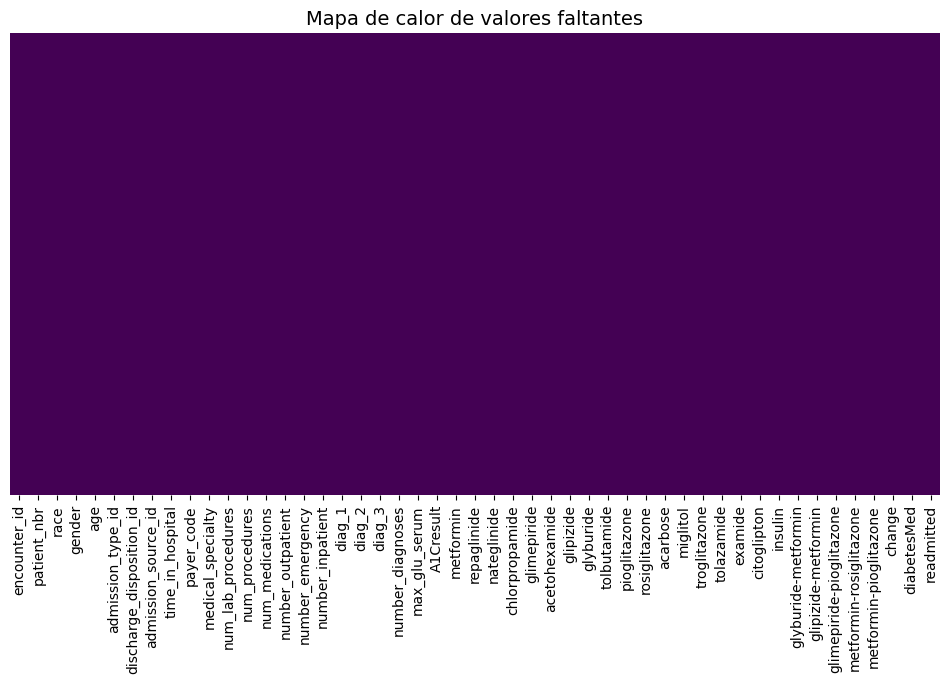

In [9]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Mapa de calor de valores faltantes", fontsize=14)
plt.show()


### Análisis descriptivo variables numericas:

In [ ]:
columnas_numericas = ["time_in_hospital","num_lab_procedures","num_procedures", "num_medications",
"number_outpatient","number_emergency","number_inpatient","number_diagnoses"]

numericas = df[columnas_numericas]
print(numericas.describe())

       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count     101766.000000       101766.000000   101766.000000    101766.000000   
mean           4.395987           43.095641        1.339730        16.021844   
std            2.985108           19.674362        1.705807         8.127566   
min            1.000000            1.000000        0.000000         1.000000   
25%            2.000000           31.000000        0.000000        10.000000   
50%            4.000000           44.000000        1.000000        15.000000   
75%            6.000000           57.000000        2.000000        20.000000   
max           14.000000          132.000000        6.000000        81.000000   

       number_outpatient  number_emergency  number_inpatient  number_diagnoses  
count      101766.000000     101766.000000     101766.000000     101766.000000  
mean            0.369357          0.197836          0.635566          7.422607  
std             1.267265          0.

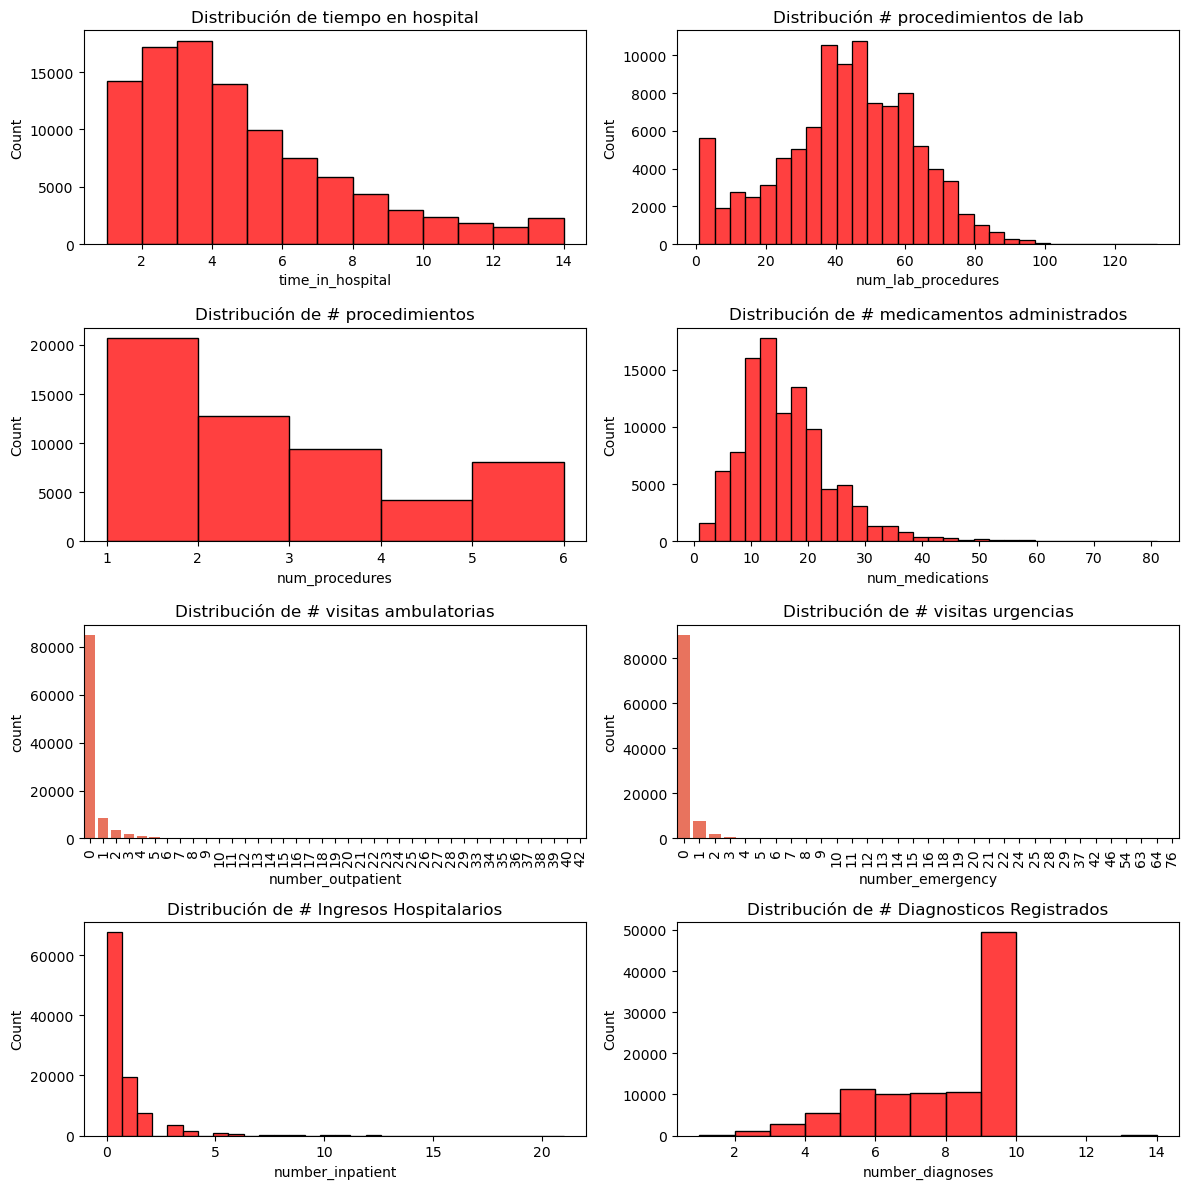

In [11]:
#DIBUJAR HISTOGRAMAS
fig, axs = plt.subplots(4, 2, figsize=(12,12))  # 2 filas, 3 columnas
axs = axs.flatten()  # Aplanamos para indexar como una lista

sns.histplot(df['time_in_hospital'], bins=range(1, 15),ax=axs[0], color='red', kde=False)
axs[0].set_title('Distribución de tiempo en hospital')

sns.histplot(df['num_lab_procedures'], bins=30,ax=axs[1], color='red', kde=False)
axs[1].set_title('Distribución # procedimientos de lab')

sns.histplot(df['num_procedures'], bins=range(1,7),ax=axs[2], color='red', kde=False)
axs[2].set_title('Distribución de # procedimientos')

sns.histplot(df['num_medications'], bins=30,ax=axs[3], color='red', kde=False)
axs[3].set_title('Distribución de # medicamentos administrados')

sns.countplot(x='number_outpatient', data=df, color='tomato', ax=axs[4])
axs[4].set_title('Distribución de # visitas ambulatorias')
axs[4].tick_params(axis='x', labelrotation=90)

sns.countplot(x='number_emergency', data=df, color='tomato', ax=axs[5])
axs[5].set_title('Distribución de # visitas urgencias')
axs[5].tick_params(axis='x', labelrotation=90)

sns.histplot(df['number_inpatient'], bins=30,ax=axs[6], color='red', kde=False)
axs[6].set_title('Distribución de # Ingresos Hospitalarios')

sns.histplot(df['number_diagnoses'], bins=range(1,15),ax=axs[7], color='red', kde=False)
axs[7].set_title('Distribución de # Diagnosticos Registrados')

plt.tight_layout()


#### Interpretación Histogramas

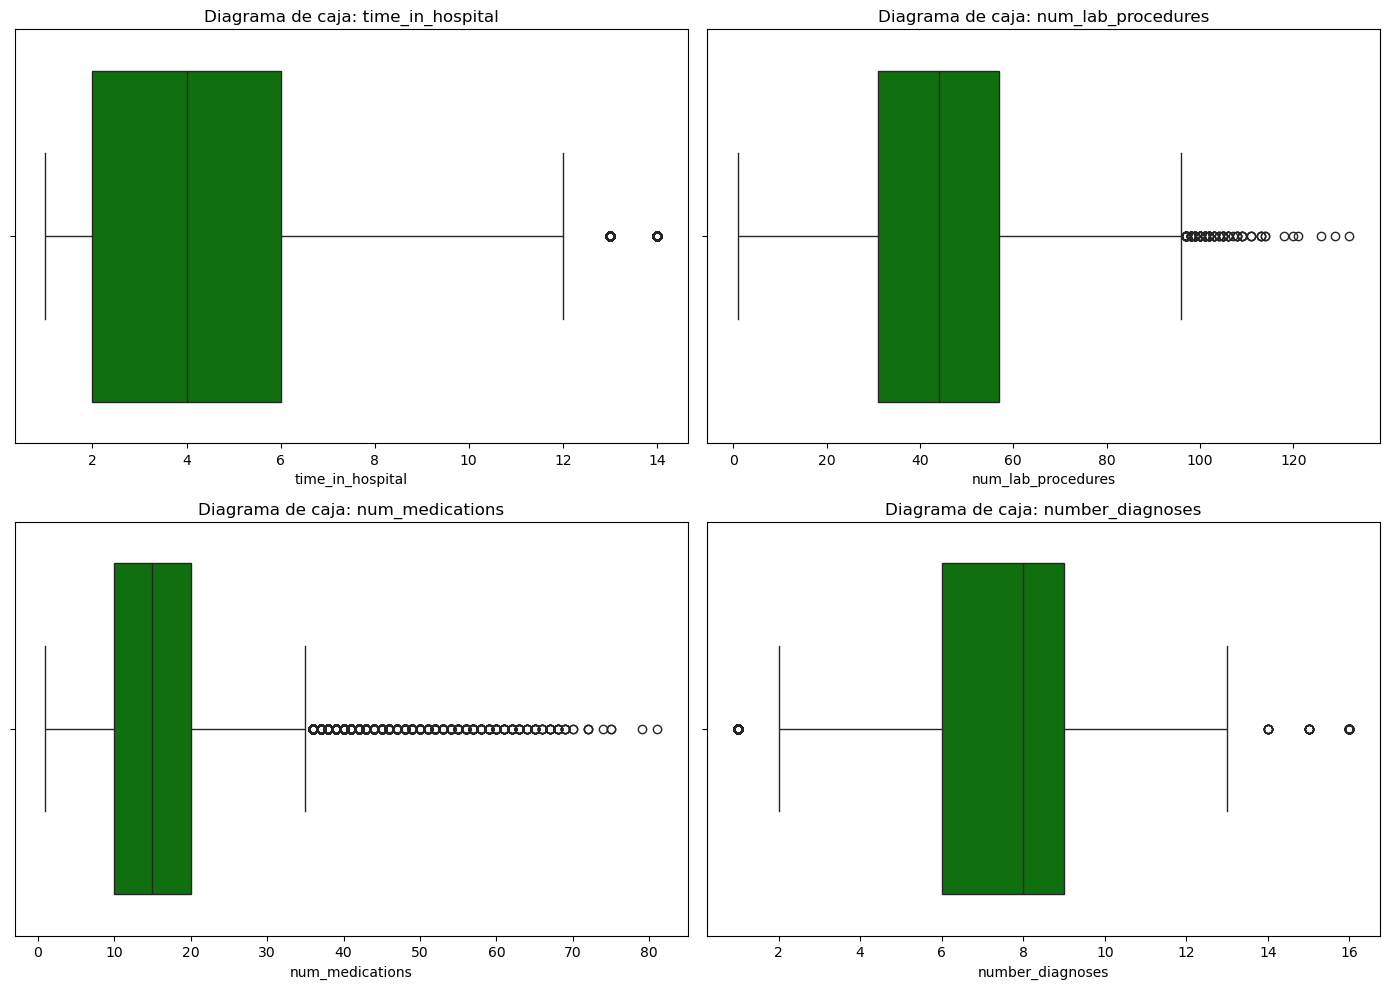

In [12]:
# Lista de variables
columnas_boxplot = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_diagnoses']

# Crear figura con 2x2 subgráficos
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

# Boxplots horizontales
for i, col in enumerate(columnas_boxplot):
    sns.boxplot(x=df[col], ax=axs[i], color='green')
    axs[i].set_title(f'Diagrama de caja: {col}', fontsize=12)
    axs[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#### Interpretación Boxplot


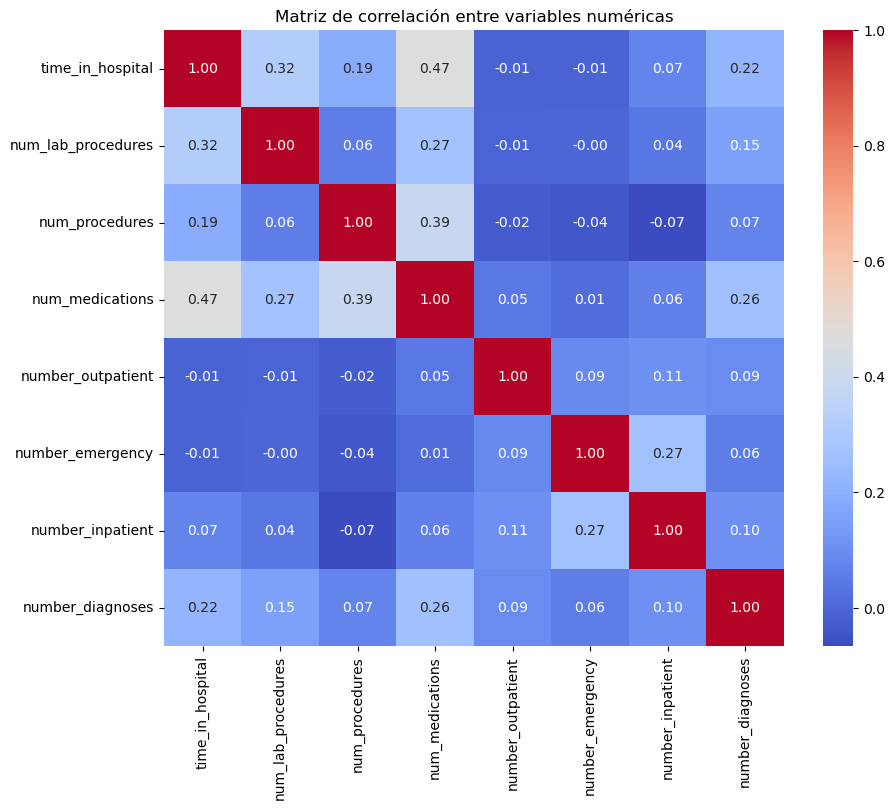

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[columnas_numericas].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

#### Interpretación Correlación

### Análisis Exploratorio Variables Categoricas

In [14]:
#CARDINALIDAD
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} categorías")

race: 5 categorías
gender: 3 categorías
age: 10 categorías
payer_code: 18 categorías
medical_specialty: 73 categorías
diag_1: 717 categorías
diag_2: 749 categorías
diag_3: 790 categorías
max_glu_serum: 4 categorías
A1Cresult: 4 categorías
metformin: 4 categorías
repaglinide: 4 categorías
nateglinide: 4 categorías
chlorpropamide: 4 categorías
glimepiride: 4 categorías
acetohexamide: 2 categorías
glipizide: 4 categorías
glyburide: 4 categorías
tolbutamide: 2 categorías
pioglitazone: 4 categorías
rosiglitazone: 4 categorías
acarbose: 4 categorías
miglitol: 4 categorías
troglitazone: 2 categorías
tolazamide: 3 categorías
examide: 1 categorías
citoglipton: 1 categorías
insulin: 4 categorías
glyburide-metformin: 4 categorías
glipizide-metformin: 2 categorías
glimepiride-pioglitazone: 2 categorías
metformin-rosiglitazone: 2 categorías
metformin-pioglitazone: 2 categorías
change: 2 categorías
diabetesMed: 2 categorías
readmitted: 3 categorías


In [15]:
#FRECUENCIA Y PROPORCION
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print("\nProporciones:")
    print(df[col].value_counts(normalize=True).round(3))



--- race ---
race
2.0    78372
0.0    19210
3.0     2037
4.0     1506
1.0      641
Name: count, dtype: int64

Proporciones:
race
2.0    0.770
0.0    0.189
3.0    0.020
4.0    0.015
1.0    0.006
Name: proportion, dtype: float64

--- gender ---
gender
0.0    54708
1.0    47055
2.0        3
Name: count, dtype: int64

Proporciones:
gender
0.0    0.538
1.0    0.462
2.0    0.000
Name: proportion, dtype: float64

--- age ---
age
7.0    26068
6.0    22483
5.0    17256
8.0    17197
4.0     9685
3.0     3775
9.0     2793
2.0     1657
1.0      691
0.0      161
Name: count, dtype: int64

Proporciones:
age
7.0    0.256
6.0    0.221
5.0    0.170
8.0    0.169
4.0    0.095
3.0    0.037
9.0    0.027
2.0    0.016
1.0    0.007
0.0    0.002
Name: proportion, dtype: float64

--- payer_code ---
payer_code
16.0    40256
7.0     32439
6.0      6274
14.0     5007
0.0      4655
8.0      3532
3.0      2533
15.0     2448
2.0      1937
10.0     1033
12.0      592
4.0       549
1.0       146
17.0      135
11.0    

In [16]:
# Crear lista con la info resumen de las variables categóricas
summary = []

for col in cat_cols:
    total = len(df)
    n_missing = df[col].isna().sum()
    n_unique = df[col].nunique(dropna=True)
    top = df[col].value_counts(dropna=True).idxmax()
    freq = df[col].value_counts(dropna=True).max()
    top_pct = (freq / total) * 100

    summary.append({
        'Variable': col,
        'Categorías únicas': n_unique,
        'Valor más frecuente': top,
        'Frecuencia': freq,
        '% del más frecuente': round(top_pct, 2),
        'Nulos': n_missing
    })

# Convertir a DataFrame para visualizar como tabla
summary_df = pd.DataFrame(summary)

# Ordenar si deseas
summary_df = summary_df.sort_values(by='Categorías únicas', ascending=False)

# Mostrar como tabla
summary_df.style.set_caption("Resumen de variables categóricas")

,Variable,Categorías únicas,Valor más frecuente,Frecuencia,% del más frecuente,Nulos
7,diag_3,790,86.000000,11555,11.350000,0
6,diag_2,749,133.000000,6752,6.630000,0
5,diag_1,717,276.000000,6862,6.740000,0
4,medical_specialty,73,71.000000,49949,49.080000,0
3,payer_code,18,16.000000,40256,39.560000,0
2,age,10,7.000000,26068,25.620000,0
0,race,5,2.000000,78372,77.010000,0
28,glyburide-metformin,4,1.000000,101060,99.310000,0
8,max_glu_serum,4,3.000000,96420,94.750000,0
9,A1Cresult,4,3.000000,84748,83.280000,0


C:\Users\Usuario\AppData\Local\Temp\ipykernel_57508\3815129339.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=orden, ax=ax, palette='Set2')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_57508\3815129339.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=orden, ax=ax, palette='Set2')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_57508\3815129339.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=orden, ax=ax, palette='Set2')
C:\Users\Usuario\AppData\Local\Temp\i

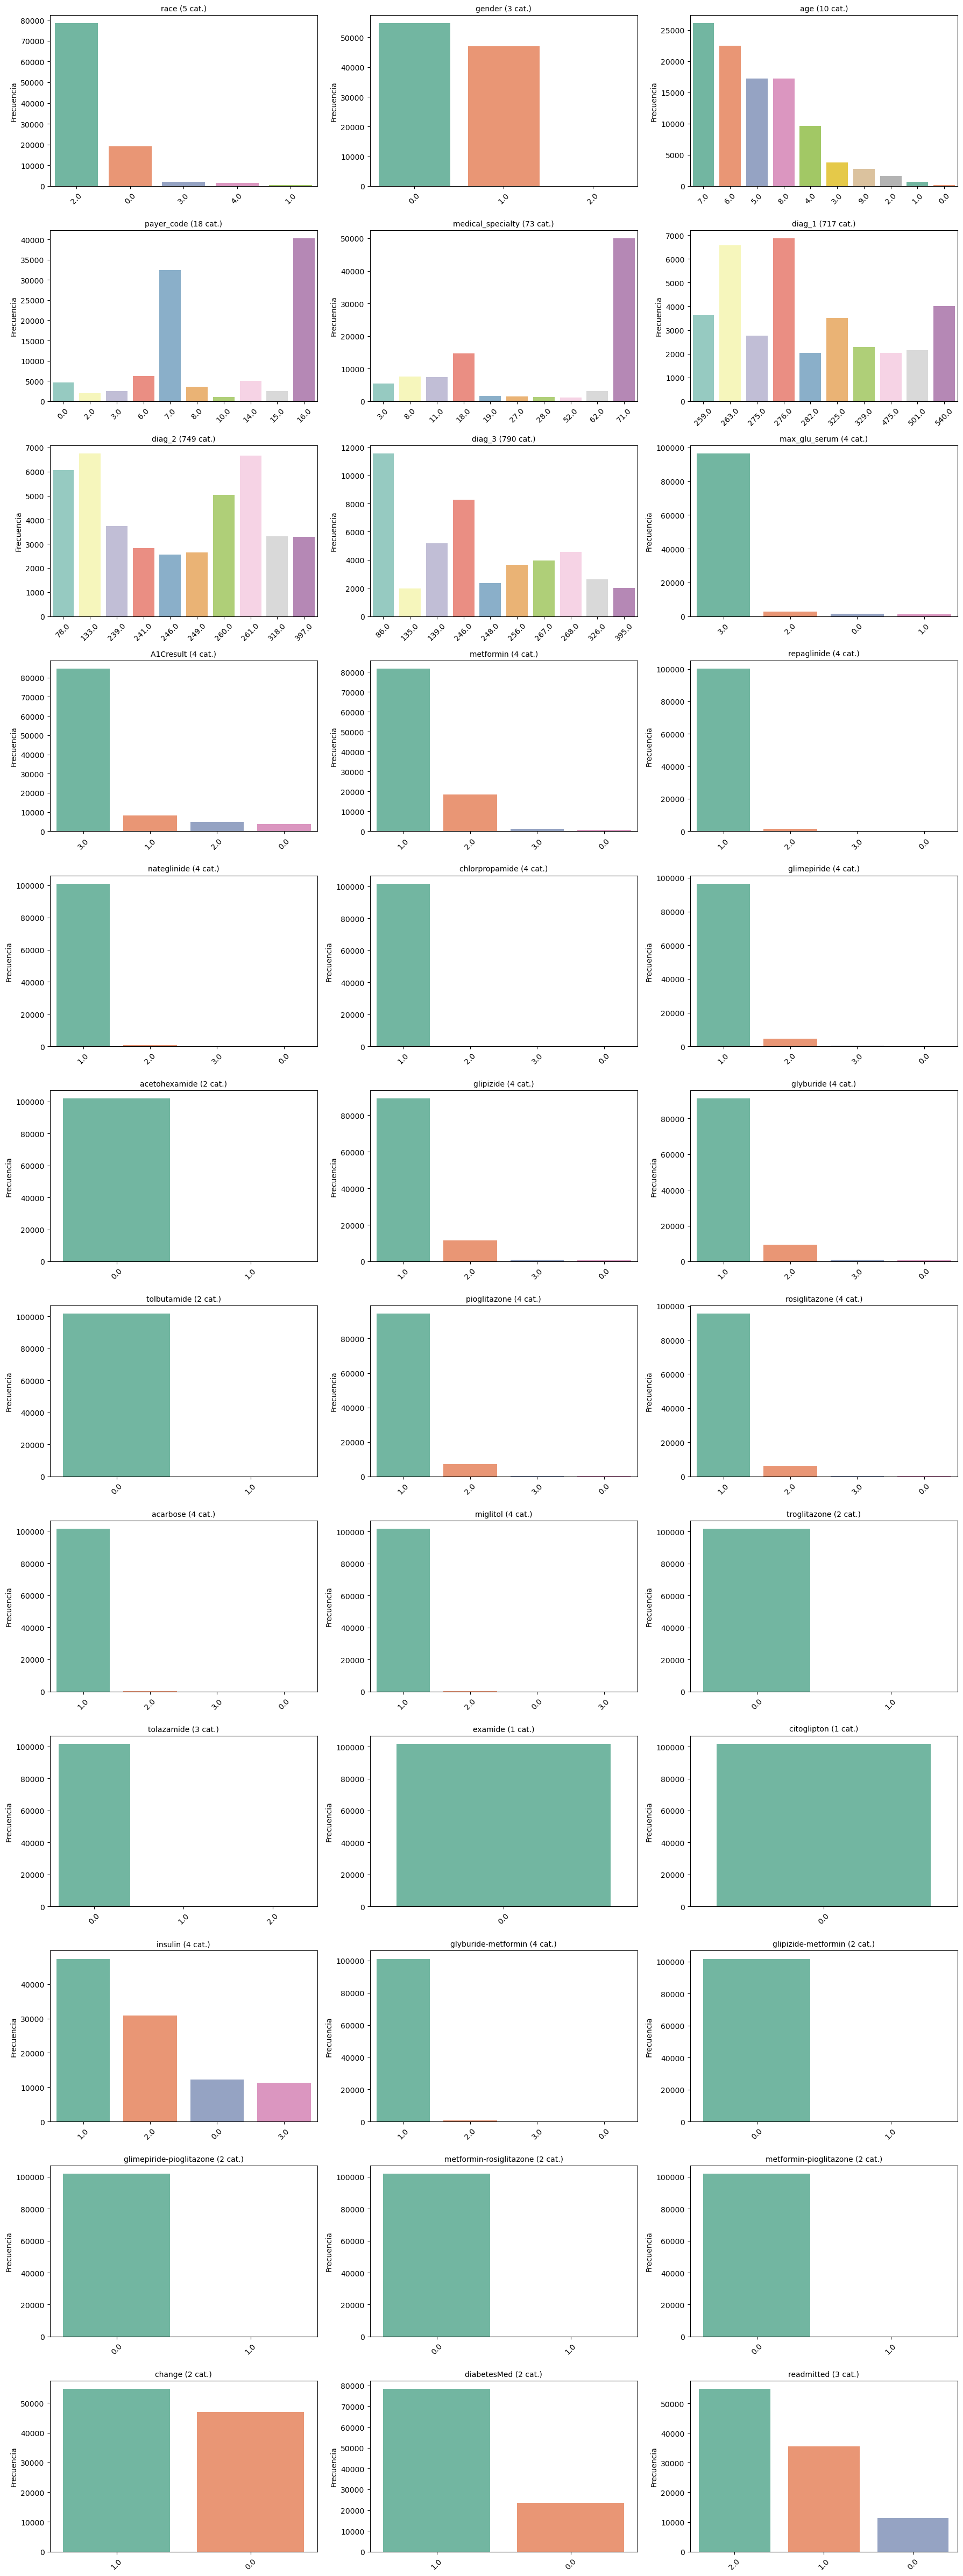

In [17]:
# Número de columnas categóricas
n_cols = len(cat_cols)

# Número de filas y columnas para la matriz de gráficos
cols = 3
rows = math.ceil(n_cols / cols)

# Crear figura y ejes
fig, axs = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axs = axs.flatten()

for i, col in enumerate(cat_cols):
    ax = axs[i]
    n_cat = df[col].nunique()

    if n_cat <= 10:
        # Ordenar categorías por frecuencia (de mayor a menor)
        orden = df[col].value_counts().sort_values(ascending=False).index
        sns.countplot(x=col, data=df, order=orden, ax=ax, palette='Set2')
    else:
        # Obtener top 10 categorías más frecuentes y ordenarlas
        top_10 = df[col].value_counts().nlargest(10)
        categorias_ordenadas = top_10.index
        frecuencias = top_10.values

        sns.barplot(x=categorias_ordenadas, y=frecuencias, ax=ax, palette='Set3')

    ax.set_title(f'{col} ({n_cat} cat.)', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


There is a lot more that you can do with outputs (such as including interactive outputs)
with your book. For more information about this, see [the Jupyter Book documentation](https://jupyterbook.org)